In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [2]:
DATA_PATH = 'SpotifyFeatures.csv'  
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Upload SpotifyFeatures.csv to /mnt/data/")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(5)

Shape: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [3]:
print("Columns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values (top 20):\n", df.isnull().sum().sort_values(ascending=False).head(20))
display(df.describe(include='all').T)

Columns:
 ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']

Dtypes:
 genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
dtype: object

Missing values (top 20):
 track_name          1
genre               0
artist_name         0
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
ins

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
genre,232725,27,Comedy,9681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_name,232725,14564,Giuseppe Verdi,1394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,232724,148614,Home,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_id,232725,176774,0UE0RhnRaEYsiYgXpyLoZc,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,232725.0,NaN,NaN,NaN,41.127502,18.189948,0.0,29.0,43.0,55.0,100.0
acousticness,232725.0,NaN,NaN,NaN,0.36856,0.354768,0.0,0.0376,0.232,0.722,0.996
danceability,232725.0,NaN,NaN,NaN,0.554364,0.185608,0.0569,0.435,0.571,0.692,0.989
duration_ms,232725.0,NaN,NaN,NaN,235122.339306,118935.909299,15387.0,182857.0,220427.0,265768.0,5552917.0
energy,232725.0,NaN,NaN,NaN,0.570958,0.263456,0.00002,0.385,0.605,0.787,0.999
instrumentalness,232725.0,NaN,NaN,NaN,0.148301,0.302768,0.0,0.0,0.000044,0.0358,0.999


In [4]:
# Drop duplicates & initial cleaning
initial = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {initial - df.shape[0]} duplicate rows")

for c in ['track_name','artist_name','genre']:
    if c in df.columns:
        df[c] = df[c].fillna('Unknown')

if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000.0

Dropped 0 duplicate rows


Detected audio features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'duration_min', 'key', 'mode', 'time_signature']
Popularity stats:
 count    232725.000000
mean         41.127502
std          18.189948
min           0.000000
25%          29.000000
50%          43.000000
75%          55.000000
max         100.000000
Name: popularity, dtype: float64


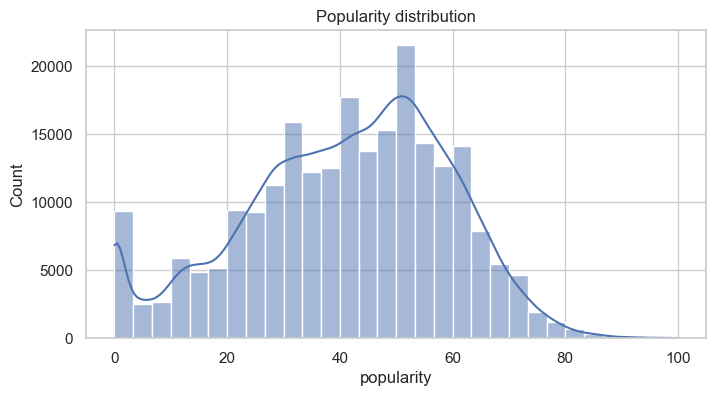

In [5]:
#Identify numeric audio features (common ones)
possible_features = [
    'danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo','duration_ms','duration_min',
    'key','mode','time_signature','chorus_hit'
]
audio_features = [f for f in possible_features if f in df.columns]
print("Detected audio features:", audio_features)

if 'popularity' in df.columns:
    print("Popularity stats:\n", df['popularity'].describe())
    plt.figure(figsize=(8,4))
    sns.histplot(df['popularity'], bins=30, kde=True)
    plt.title('Popularity distribution')
    plt.show()

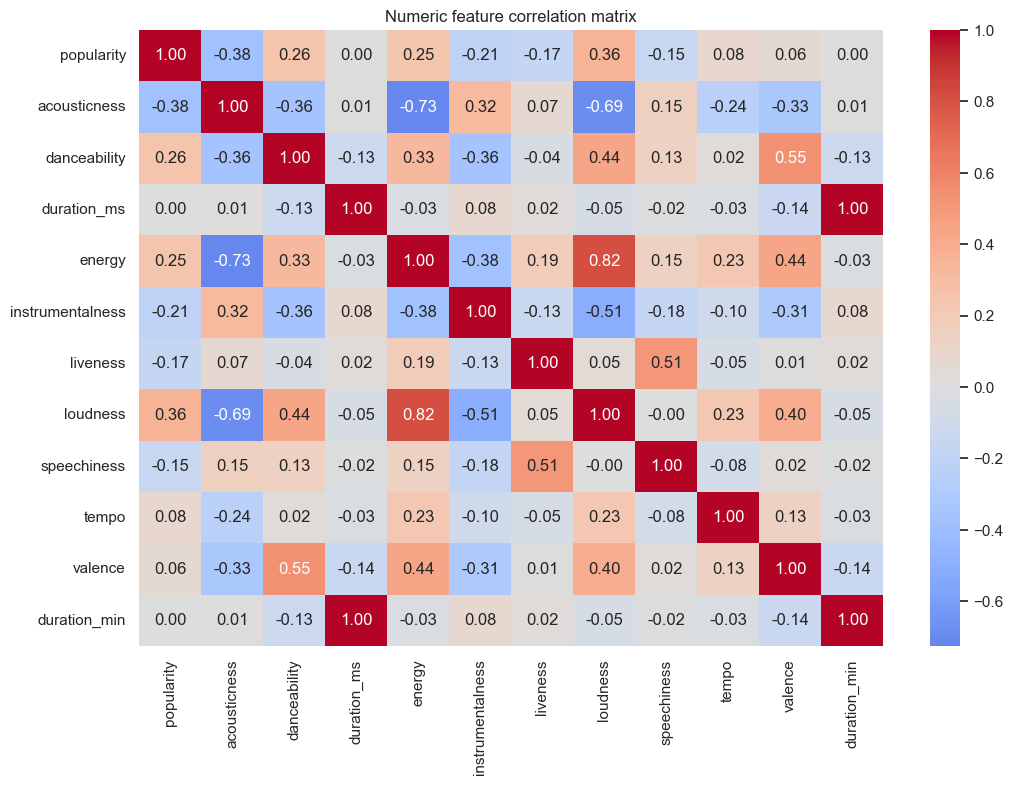

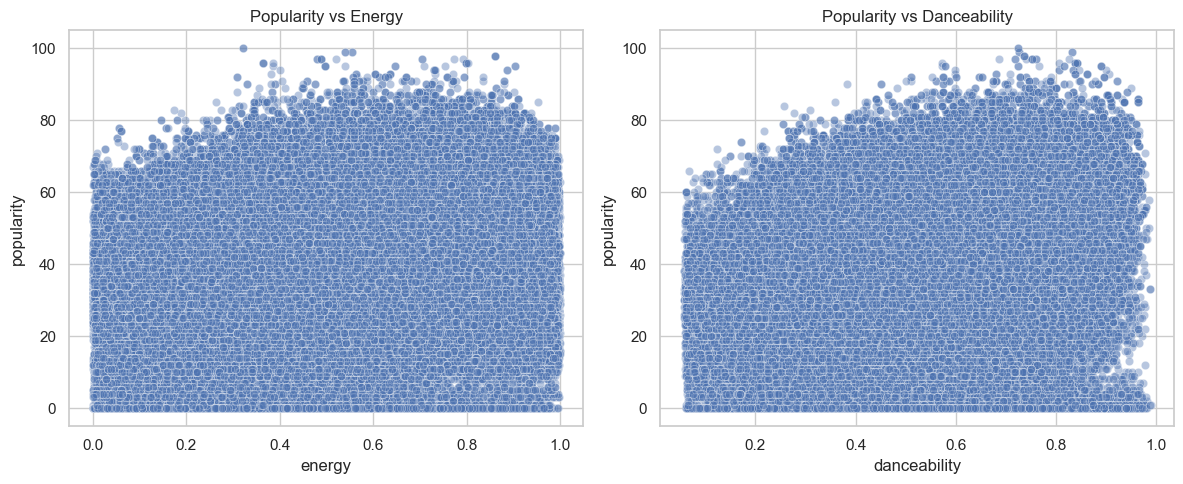

In [6]:
# EDA - correlations and scatter plots
# Correlation heatmap for numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Numeric feature correlation matrix')
plt.show()

if 'popularity' in df.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.scatterplot(x='energy', y='popularity', data=df, alpha=0.4)
    plt.title('Popularity vs Energy')
    plt.subplot(1,2,2)
    sns.scatterplot(x='danceability', y='popularity', data=df, alpha=0.4)
    plt.title('Popularity vs Danceability')
    plt.tight_layout()
    plt.show()

In [7]:
# Feature engineering - create 'is_hit' label 
if 'popularity' in df.columns:
    df['is_hit'] = (df['popularity'] >= 70).astype(int)
    print("is_hit distribution:\n", df['is_hit'].value_counts(normalize=True))
else:
    print("No 'popularity' column detected. We'll skip hit classification.")

is_hit distribution:
 is_hit
0    0.961323
1    0.038677
Name: proportion, dtype: float64


In [8]:
# Prepare data for ML - choose features and target
features = [f for f in audio_features if f in df.columns]
print("Using features:", features)

df_ml = df.copy().dropna(subset=features) 

Using features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'duration_min', 'key', 'mode', 'time_signature']


In [9]:
# Split data for regression (popularity prediction)
if 'popularity' in df_ml.columns:
    X = df_ml[features]
    y = df_ml['popularity']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Regression split sizes:", X_train.shape, X_test.shape)
else:
    print("No popularity column available for regression.")

Regression split sizes: (186180, 14) (46545, 14)


In [10]:
# Preprocessing pipeline (numeric imputer + scaler)
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

In [11]:
# Regression model pipeline (RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor

reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

reg_pipeline.fit(X_train, y_train)

y_pred = reg_pipeline.predict(X_test)
print("Regression Metrics:")
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("  MAE:", mean_absolute_error(y_test, y_pred))
print("  R2:", r2_score(y_test, y_pred))

Regression Metrics:
  RMSE: 11.805632400395915
  MAE: 8.35087832854177
  R2: 0.5814143518448285


acousticness        0.222430
speechiness         0.101018
loudness            0.089940
danceability        0.088784
valence             0.083951
liveness            0.074623
energy              0.072744
instrumentalness    0.071146
tempo               0.068744
duration_min        0.063448
duration_ms         0.063173
dtype: float64


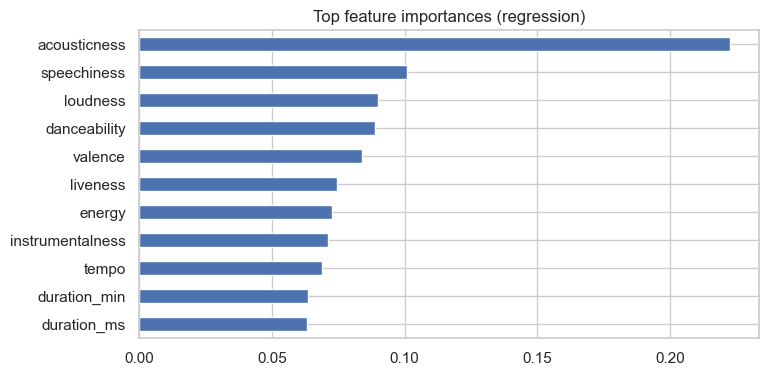

In [12]:
# Feature importance (approximate, from RandomForest)
rf = reg_pipeline.named_steps['regressor']
importances = rf.feature_importances_
fi = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
print(fi.head(15))
plt.figure(figsize=(8,4))
fi.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top feature importances (regression)')
plt.show()

Classification split sizes: (186180, 14) (46545, 14)
Classification accuracy: 0.9889139542378343
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     44745
           1       0.95      0.75      0.84      1800

    accuracy                           0.99     46545
   macro avg       0.97      0.87      0.92     46545
weighted avg       0.99      0.99      0.99     46545



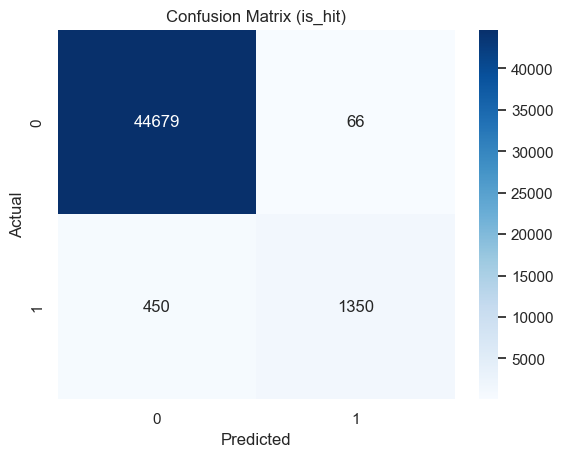

In [13]:
# Classification example: predict is_hit
if 'is_hit' in df_ml.columns:
    Xc = df_ml[features]
    yc = df_ml['is_hit']
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
    print("Classification split sizes:", Xc_train.shape, Xc_test.shape)

    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])

    clf_pipeline.fit(Xc_train, yc_train)
    yc_pred = clf_pipeline.predict(Xc_test)

    print("Classification accuracy:", accuracy_score(yc_test, yc_pred))
    print("Classification report:\n", classification_report(yc_test, yc_pred))
    cm = confusion_matrix(yc_test, yc_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (is_hit)')
    plt.show()
else:
    print("No is_hit label available — can't do hit classification.")

In [14]:
#  Save final models 
MODEL_DIR = '/mnt/data/models'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(reg_pipeline, os.path.join(MODEL_DIR, 'popularity_regressor.joblib'))
if 'is_hit' in df_ml.columns:
    joblib.dump(clf_pipeline, os.path.join(MODEL_DIR, 'hit_classifier.joblib'))
print("Saved models to", MODEL_DIR)

Saved models to /mnt/data/models


In [15]:
# Cell 15: Quick predictions on new rows 
# Use the trained reg_pipeline and clf_pipeline to predict
sample = X_test.sample(3, random_state=1)
print("Sample rows:\n", sample)
print("Predicted popularity (regressor):", reg_pipeline.predict(sample))
if 'is_hit' in df_ml.columns:
    print("Predicted hit (classifier):", clf_pipeline.predict(sample))

Sample rows:
         danceability  energy  loudness  speechiness  acousticness  \
45359          0.620   0.990     0.180       0.0698      0.000163   
27925          0.406   0.902    -5.990       0.0635      0.003520   
132124         0.655   0.602   -10.148       0.0617      0.027700   

        instrumentalness  liveness  valence    tempo  duration_ms  \
45359           0.000108    0.0894    0.524  109.935       234545   
27925           0.000000    0.0924    0.693  171.945       199560   
132124          0.000001    0.3270    0.593  172.196       199056   

        duration_min key   mode time_signature  
45359       3.909083   E  Minor            4/4  
27925       3.326000  G#  Minor            4/4  
132124      3.317600   C  Major            4/4  
Predicted popularity (regressor): [36.8735     43.11004167 38.944     ]
Predicted hit (classifier): [0 0 0]


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
import joblib

df = pd.read_csv('SpotifyFeatures.csv')

df['hit'] = df['popularity'].apply(lambda x: 1 if x >= 60 else 0)

features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

df = df.dropna(subset=features + ['popularity', 'hit'])

X = df[features]
y_reg = df['popularity']
y_clf = df['hit']

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_clf_scaled = scaler.transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_reg_train)

clf_model = LogisticRegression()
clf_model.fit(X_train_clf_scaled, y_clf_train)

reg_pred = reg_model.predict(X_test_scaled)
print("Regression MSE:", mean_squared_error(y_reg_test, reg_pred))

clf_pred = clf_model.predict(X_test_clf_scaled)
print("Classification Accuracy:", accuracy_score(y_clf_test, clf_pred))

joblib.dump(reg_model, 'regression_model.pkl')
joblib.dump(clf_model, 'classification_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Models and scaler saved successfully!")


Regression MSE: 255.14924617301497
Classification Accuracy: 0.8416800945321732
Models and scaler saved successfully!


In [5]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
!python train_recommender.py

Loading dataset...
Preparing preprocessing pipeline...
Fitting preprocessor to dataset...
Feature matrix shape: (232725, 37)
Fitting NearestNeighbors (cosine)...
Saving artifacts to models/ ...
Done. Artifacts saved:
 - models/preprocessor.joblib
 - models/nn.joblib
 - models/metadata.joblib
You can now run the Streamlit app (app.py).


In [58]:
pip install thefuzz

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 3.1 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.4 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [rapidfuzz]
   ---------------------------------------- 2/2 [thefuzz]

Note: you may need to restart the kernel to use updated packages.


In [61]:
pip install streamlit pandas scikit-learn joblib thefuzz

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!streamlit run App.py